In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import os
from IPython.display import Image, display

# =====================================================================
# 1. CONFIGURATION 
# =====================================================================
# Put everything between '', configurate for yourself.

# Input: 'Data_input/' when using the subfolder
FILE_DISPENSER    = 'Data_input/20260411_15_synergistic_cellamounts.csv'
FILE_PLATE_READER = 'Data_input/Alive_Cells_Result.csv'

#Output: 'Data_output/' is for putting it into the subfolder
FILE_OUTPUT       = 'Data_output/Example_list_output.csv'
PDF_FILE_OUTPUT   = 'Data_output/Exp0011_microscopy_72h_3000c'

# R-script pathway: Change for you
RSCRIPT_PATH      = "C:/Program Files/R/R-4.5.3/bin/Rscript.exe"

# Lists of controls and what to remove: Leave 'Evaporation_Control' -> Important for the script
POSITIVE_CONTROLS = ['PC']        
NEGATIVE_CONTROLS = ['DMSO', 'NC', 'DMSO C']    
REMOVE_LIST       = ['Control', 'Evaporation_Control', 'Empty', 'Buffer']

# Name of the drugs
ANCHOR_DRUG       = 'Abemaciclib'     
PARTNER_DRUG      = 'Cytarabine'     

# Concentrations of the drugs: it will bin them 
TARGET_BINS = [0.0, 0.01, 0.025, 0.0585, 0.342, 2.00, 5, 0.25, 1.00, 2.92, 8.5, 25.0, 75.0]
# Collection of used concentrations:
#20260401-6x6: Rab + Cyt [0.0, 0.103, 0.309, 0.926, 2.78, 8.33, 25.0, 75.0, 0.0043, 0.0129, 0.0387, 0.116, 0.347, 1.04, 3.13]
#20260401-6x6: Rab + Clad [0.0, 0.103, 0.309, 0.926, 2.78, 8.33, 25.0, 75.0, 0.0069, 0.0207, 0.062, 0.186, 0.556, 1.67, 5.0]
#20260414-6x6: Abe + Cyt [0.0, 0.032, 0.116, 0.42, 1.52, 5.52, 20.0, 40.0, 0.04, 0.0761, 0.145, 0.276, 0.525, 1.0, 5.0]
#20260414-6x6: Abe + Clad [0.0, 0.032, 0.116, 0.42, 1.52, 5.52, 20.0, 40.0, 0.08, 0.183, 0.418, 0.956, 2.19, 5.0, 10.0]
#20260413-4x4: Rab + Cyt [0.0, 0.01, 0.025, 0.0585, 0.342, 2.00, 5, 0.25, 1.00, 2.92, 8.5, 25.0, 75.0]

# Remove some concentrations again if they outlie
REMOVE_CONCENTRATIONS = []

# ---- CUSTOMIZATION OPTIONS ----
SWAP_AXES       = False             # Set to True to flip X and Y axes for the txt files
READOUT_LABEL   = 'Confluence [%]'  # Change to 'Viability [%]' for your csv files
HEATMAP_COLOR   = 'viridis'          # Try: 'plasma', 'viridis', 'magma', 'inferno', or 'cividis'

In [4]:
# =====================================================================
# 2. DATA PROCESSING & MERGING (UPDATED WELL MATCHING)
# =====================================================================

if FILE_PLATE_READER.endswith('.txt'):
    reader_df = pd.read_csv(FILE_PLATE_READER, sep='\t', skiprows=1)
    last_row = reader_df.iloc[-1:]
    reader_clean = last_row.melt(id_vars=['Date Time', 'Elapsed'], var_name='Well', value_name='Signal')
    reader_clean = reader_clean.dropna(subset=['Signal']).copy()
else:
    reader_df = pd.read_csv(FILE_PLATE_READER)
    reader_clean = reader_df[['Well', 'Signal']].dropna(subset=['Signal']).copy()

# Fix well names safely
reader_clean['Well'] = reader_clean['Well'].astype(str).str.replace(r'([A-Za-z])0(\d)', r'\1\2', regex=True)

dispense_df = pd.read_csv(FILE_DISPENSER)
dispense_df['Dispensed well'] = dispense_df['Dispensed well'].astype(str).str.replace(r'([A-Za-z])0(\d)', r'\1\2', regex=True)

dispense_df['Drug_Idx'] = dispense_df.groupby(['Dispensed well']).cumcount() + 1
drugs = dispense_df.pivot(index='Dispensed well', columns='Drug_Idx', values='Fluid name')
concs = dispense_df.pivot(index='Dispensed well', columns='Drug_Idx', values='Dispensed concentration')

dispense_wide = pd.concat([drugs, concs], axis=1).reset_index().rename(columns={'Dispensed well': 'Well'})
dispense_wide.columns = ['Well'] + [f'Drug{i}' for i in drugs.columns] + [f'Conc{i}' for i in concs.columns]

merged_df = pd.merge(reader_clean, dispense_wide, on='Well', how='inner')

if 'Drug2' not in merged_df.columns:
    merged_df['Drug2'] = 'None'
    merged_df['Conc2'] = 0.0

merged_df['Drug1'] = merged_df['Drug1'].fillna('Evaporation_Control')
merged_df['Drug2'] = merged_df['Drug2'].fillna('None')
merged_df[['Conc1', 'Conc2']] = merged_df[['Conc1', 'Conc2']].fillna(0.0)

In [5]:
# =====================================================================
# 3. BINNING & NORMALIZATION
# =====================================================================

def snap(v):
    if pd.isna(v) or v == 0.0: return 0.0
    return min(TARGET_BINS, key=lambda x: abs(x - v))

merged_df['Conc1'] = merged_df['Conc1'].apply(snap)
merged_df['Conc2'] = merged_df['Conc2'].apply(snap)

merged_df = merged_df[~merged_df['Conc1'].isin(REMOVE_CONCENTRATIONS)]
merged_df = merged_df[~merged_df['Conc2'].isin(REMOVE_CONCENTRATIONS)]

mean_pc = merged_df[merged_df['Drug1'].isin(POSITIVE_CONTROLS)]['Signal'].mean()
mean_dmso = merged_df[merged_df['Drug1'].isin(NEGATIVE_CONTROLS)]['Signal'].mean()

if pd.isna(mean_pc) or len(merged_df[merged_df['Drug1'].isin(POSITIVE_CONTROLS)]) == 0:
    merged_df['Viability_pct'] = (merged_df['Signal'] / mean_dmso) * 100
else:
    merged_df['Viability_pct'] = ((merged_df['Signal'] - mean_pc) / (mean_dmso - mean_pc)) * 100

df = merged_df[~merged_df['Drug1'].isin(REMOVE_LIST)].copy()

In [6]:
# =====================================================================
# 4. STANDARDIZATION & CSV EXPORT
# =====================================================================

all_found = set(df['Drug1'].unique()).union(set(df['Drug2'].unique()))
exclude = POSITIVE_CONTROLS + NEGATIVE_CONTROLS + REMOVE_LIST + ['None', 'nan', 'NaN']
active_compounds = [str(d) for d in all_found if str(d) not in exclude and pd.notna(d)]

if len(active_compounds) >= 1 and ANCHOR_DRUG not in active_compounds: ANCHOR_DRUG = active_compounds[0]
if len(active_compounds) >= 2 and PARTNER_DRUG not in active_compounds: PARTNER_DRUG = active_compounds[1]

def standardize(row):
    if row['Drug1'] in POSITIVE_CONTROLS: return None
    d1, d2 = str(row['Drug1']), str(row['Drug2'])
    c1, c2 = row['Conc1'], row['Conc2']
    well, signal = row['Well'], row['Signal']
    
    if d1 in NEGATIVE_CONTROLS: 
        return pd.Series([well, ANCHOR_DRUG, PARTNER_DRUG, 0.0, 0.0, signal, row['Viability_pct']])
    if d1 == PARTNER_DRUG and d2 == ANCHOR_DRUG:
        return pd.Series([well, ANCHOR_DRUG, PARTNER_DRUG, c2, c1, signal, row['Viability_pct']])
    if d1 == ANCHOR_DRUG and d2 == PARTNER_DRUG:
        return pd.Series([well, ANCHOR_DRUG, PARTNER_DRUG, c1, c2, signal, row['Viability_pct']])
    if d1 == ANCHOR_DRUG and (d2 == 'nan' or d2 == 'None'):
        return pd.Series([well, ANCHOR_DRUG, PARTNER_DRUG, c1, 0.0, signal, row['Viability_pct']])
    if d1 == PARTNER_DRUG and (d2 == 'nan' or d2 == 'None'):
        return pd.Series([well, ANCHOR_DRUG, PARTNER_DRUG, 0.0, c1, signal, row['Viability_pct']])
    return None

df_final = df.apply(standardize, axis=1).dropna()
df_final.columns = ['Well', 'Drug1', 'Drug2', 'Conc1', 'Conc2', 'Signal', 'Viability_pct']

# --- SAFE SWAPPING LOGIC ---
df_export = df_final.copy()
export_anchor = ANCHOR_DRUG
export_partner = PARTNER_DRUG

if SWAP_AXES:
    # Swap columns safely in a new dataframe
    df_export = df_export[['Well', 'Drug2', 'Drug1', 'Conc2', 'Conc1', 'Signal', 'Viability_pct']]
    df_export.columns = ['Well', 'Drug1', 'Drug2', 'Conc1', 'Conc2', 'Signal', 'Viability_pct']
    export_anchor, export_partner = PARTNER_DRUG, ANCHOR_DRUG

print(f"-> Exporting Pipeline for: X-Axis = {export_anchor} | Y-Axis = {export_partner}")

df_export.to_csv(FILE_OUTPUT, index=False)
display(df_export.head())

-> Exporting Pipeline for: X-Axis = Rabusertib | Y-Axis = Cytarabine


,Well,Drug1,Drug2,Conc1,Conc2,Signal,Viability_pct
0,B2,Rabusertib,Cytarabine,25.0,0.0,36.0,34.158416
1,B3,Rabusertib,Cytarabine,25.0,0.0,-324.0,-500.495050
2,B4,Rabusertib,Cytarabine,25.0,0.0,57.0,65.346535
3,B5,Rabusertib,Cytarabine,0.0,2.0,163.0,222.772277
4,B6,Rabusertib,Cytarabine,0.0,2.0,-15.0,-41.584158



--- Generating Python Heatmap ---


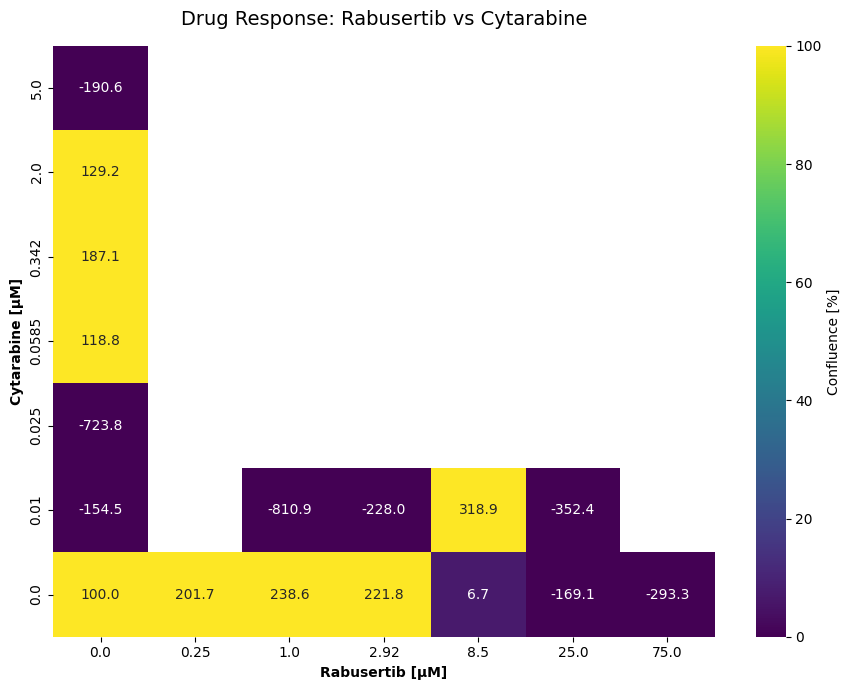

In [7]:
# =====================================================================
# 5. GENERATE PYTHON HEATMAP (SEABORN)
# =====================================================================
# Using seaborn to get a heatmap: For overfew: --> Does the data look as it was expected?
# If not --> Problems with the code!

print(f"\n--- Generating Python Heatmap ---")

# Create pivot table from the EXPORTED data (which already handled the swap)
pivot_df = df_export.pivot_table(index='Conc2', columns='Conc1', values='Viability_pct', aggfunc='mean')

# Sort the Y-axis so 0 is at the bottom
pivot_df = pivot_df.sort_index(ascending=False)

plt.figure(figsize=(9, 7))

# Draw the heatmap using our custom color and custom label!
sns.heatmap(pivot_df, 
            cmap=HEATMAP_COLOR, 
            annot=True, 
            fmt=".1f", 
            vmin=0,     
            vmax=100,   
            cbar_kws={'label': READOUT_LABEL})

plt.xlabel(f"{export_anchor} [µM]", fontweight='bold')
plt.ylabel(f"{export_partner} [µM]", fontweight='bold')
plt.title(f"Drug Response: {export_anchor} vs {export_partner}", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [8]:
#ACCESS R: IMPORTANT PACKAGES to install in R before!!!
# install.packages("remotes")
# remotes::install_github("ocbe-uio/bayesynergy")
# Seperate file for R: See "run_bayesynergy.R"!!!

In [9]:
# =====================================================================
# 6. RUN R PIPELINE
# =====================================================================
# I asked LLM: Its accessing the R script:'run_bayesynergy.R' --> Im not sure what it does but it works

print(f"\n--- Starting R Pipeline ---")

if not os.path.exists("run_bayesynergy.R"):
    print("Error: Could not find 'run_bayesynergy.R' in this folder.")
else:
    command = [
        RSCRIPT_PATH, 
        "run_bayesynergy.R", 
        FILE_OUTPUT,     
        export_anchor,   # <--- Now safely passes the swapped X-axis
        export_partner,  # <--- Now safely passes the swapped Y-axis
        PDF_FILE_OUTPUT if PDF_FILE_OUTPUT.strip() != "" else "DEFAULT",
        READOUT_LABEL,   
        HEATMAP_COLOR    
    ]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        print(result.stdout)
        print("R Script finished!")
    except subprocess.CalledProcessError as e:
        print("An error occurred while running R:")
        print(e.stderr)


--- Starting R Pipeline ---


Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\janni\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1052, in _bootstrap_inner
    self.run()
  File "c:\Users\janni\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\janni\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 989, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\janni\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1597, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "c:\Users\janni\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 


[R] Running Bayesynergy for: Rabusertib + Cytarabine ...

SAMPLING FOR MODEL 'gp_grid' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000712 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 7.12 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 3.251 seconds (Warm-up)
Chain 1:             